<a href="https://colab.research.google.com/github/kalyankargouri/Deep-Learning/blob/main/DLexper1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
def build_model(initializer, optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu',
                              kernel_initializer=initializer,
                              input_shape=(784,)),
        tf.keras.layers.Dense(64, activation='relu',
                              kernel_initializer=initializer),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [4]:
model_random = build_model(
    tf.keras.initializers.RandomNormal(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_random = model_random.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5803 - loss: 1.6071 - val_accuracy: 0.7992 - val_loss: 0.8720
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8337 - loss: 0.6569 - val_accuracy: 0.8668 - val_loss: 0.4985
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8742 - loss: 0.4602 - val_accuracy: 0.8906 - val_loss: 0.3957
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8912 - loss: 0.3884 - val_accuracy: 0.9012 - val_loss: 0.3488
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9008 - loss: 0.3503 - val_accuracy: 0.9086 - val_loss: 0.3212
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9072 - loss: 0.3252 - val_accuracy: 0.9136 - val_loss: 0.3020
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9125 - loss: 0.3066 - val_accuracy: 0.9183 - val_loss: 0.2871
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9168 - loss: 0.2915 - val_accuracy: 0.

In [5]:
model_xavier = build_model(
    tf.keras.initializers.GlorotUniform(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_xavier = model_xavier.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7056 - loss: 1.2020 - val_accuracy: 0.8578 - val_loss: 0.5829
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8729 - loss: 0.4937 - val_accuracy: 0.8919 - val_loss: 0.4029
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8943 - loss: 0.3876 - val_accuracy: 0.9040 - val_loss: 0.3448
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9044 - loss: 0.3426 - val_accuracy: 0.9117 - val_loss: 0.3136
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9118 - loss: 0.3148 - val_accuracy: 0.9182 - val_loss: 0.2922
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9171 - loss: 0.2944 - val_accuracy: 0.9229 - val_loss: 0.2756
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9213 - loss: 0.2778 - val_accuracy: 0.9265 - val_loss: 0.2619
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9251 - loss: 0.2638 - val_accuracy: 0.

In [6]:
model_he = build_model(
    tf.keras.initializers.HeNormal(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_he = model_he.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6873 - loss: 1.2097 - val_accuracy: 0.8540 - val_loss: 0.5825
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8717 - loss: 0.4906 - val_accuracy: 0.8929 - val_loss: 0.3962
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8939 - loss: 0.3845 - val_accuracy: 0.9037 - val_loss: 0.3377
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9050 - loss: 0.3389 - val_accuracy: 0.9108 - val_loss: 0.3061
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9121 - loss: 0.3106 - val_accuracy: 0.9174 - val_loss: 0.2846
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9177 - loss: 0.2895 - val_accuracy: 0.9219 - val_loss: 0.2678
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9219 - loss: 0.2724 - val_accuracy: 0.9265 - val_loss: 0.2538
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9260 - loss: 0.2578 - val_accuracy: 0.

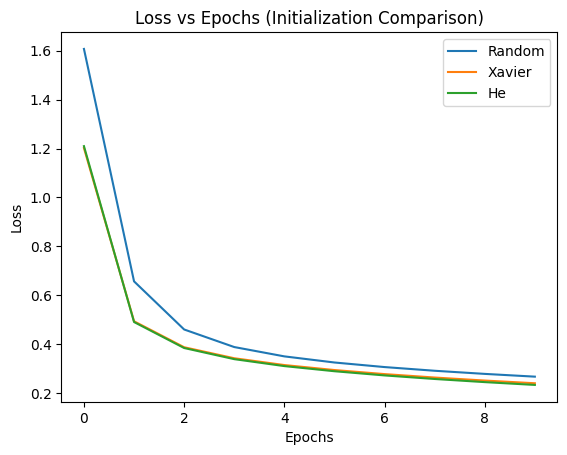

In [7]:
plt.plot(history_random.history['loss'], label='Random')
plt.plot(history_xavier.history['loss'], label='Xavier')
plt.plot(history_he.history['loss'], label='He')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (Initialization Comparison)")
plt.legend()
plt.show()


In [8]:
model_adam = build_model(
    tf.keras.initializers.HeNormal(),
    tf.keras.optimizers.Adam()
)

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9133 - loss: 0.3075 - val_accuracy: 0.9533 - val_loss: 0.1526
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9611 - loss: 0.1307 - val_accuracy: 0.9656 - val_loss: 0.1097
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9731 - loss: 0.0904 - val_accuracy: 0.9723 - val_loss: 0.0913
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9801 - loss: 0.0676 - val_accuracy: 0.9748 - val_loss: 0.0819
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0513 - val_accuracy: 0.9753 - val_loss: 0.0792
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9887 - loss: 0.0398 - val_accuracy: 0.9765 - val_loss: 0.0788
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9918 - loss: 0.0308 - val_accuracy: 0.9759 - val_loss: 0.0815
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9937 - loss: 0.0247 - val_accuracy: 0.

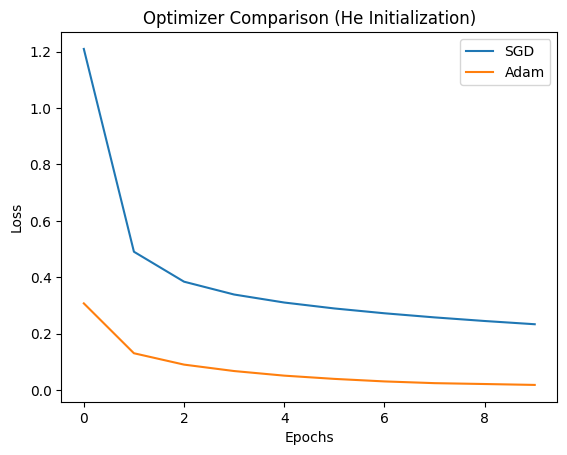

In [9]:
plt.plot(history_he.history['loss'], label='SGD')
plt.plot(history_adam.history['loss'], label='Adam')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Optimizer Comparison (He Initialization)")
plt.legend()
plt.show()
